In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
dataset = pd.read_csv("hour.csv")


In [ ]:
X = dataset.drop(
    columns=["instant", "cnt", "casual", "registered", "dteday"]
)

y = dataset["cnt"]

In [ ]:
print(dataset.columns[-1])

cnt


In [ ]:
print(X.columns)
print(X.shape)
print(y.shape)

Index(['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed'],
      dtype='object')
(17379, 12)
(17379,)


In [ ]:
print(X.isnull().sum())

season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
dtype: int64


In [ ]:
from sklearn.model_selection  import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
print(X_train)

[[-1.36363715 -1.00410827 -1.61573901 ... -1.62031134 -0.3994488
   0.27866867]
 [ 1.34693531 -1.00410827  1.00297496 ...  0.13822833 -1.07374273
  -0.69771358]
 [ 1.34693531 -1.00410827  1.5849114  ... -0.12584281  1.93464557
   0.27866867]
 ...
 [ 0.44341116 -1.00410827  0.42103853 ...  1.45742327 -1.02187397
   0.7668598 ]
 [-1.36363715 -1.00410827 -1.32477079 ... -1.62031134  0.11923884
   1.8650854 ]
 [ 1.34693531  0.99590854  1.00297496 ...  0.13822833  1.05287659
  -0.20952245]]


In [ ]:
print(X_test)

[[ 0.44341116  0.99590854 -0.16089791 ...  1.2815693  -1.85177419
   0.03416424]
 [-1.36363715  0.99590854 -1.61573901 ... -1.44445738 -1.1256115
   0.27866867]
 [ 1.34693531 -1.00410827  1.00297496 ... -1.00511265  0.1711076
   0.7668598 ]
 ...
 [-1.36363715 -1.00410827 -1.61573901 ... -1.70852852 -0.19197375
   1.37689427]
 [ 1.34693531  0.99590854  1.29394318 ... -0.03762564  0.741664
  -0.20952245]
 [ 1.34693531 -1.00410827  1.5849114  ... -0.91689548 -0.71066138
  -0.20952245]]


In [ ]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.38798115831391333
MAE: 104.80335089554426
MSE: 19379.82836765172
RMSE: 139.21145199893476


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

poly = PolynomialFeatures(degree=2)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred = poly_reg.predict(X_test_poly)

In [ ]:

print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.5419772919048558
MAE: 91.25342411435724
MSE: 14503.477453270589
RMSE: 120.4303842610767


In [ ]:
from sklearn.svm import SVR
svr = SVR(kernel="rbf",C=100,gamma="scale",epsilon=0.1)
svr.fit(X_train, y_train)

y_pred = svr.predict(X_test)

In [ ]:
print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.5973340551899481
MAE: 67.94266839532305
MSE: 12750.582773593274
RMSE: 112.9184784417204


In [ ]:
from sklearn.tree import DecisionTreeRegressor
dtr = DecisionTreeRegressor(random_state=42)
dtr.fit(X_train, y_train)

y_pred = dtr.predict(X_test)

In [ ]:
print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.8924640066958633
MAE: 34.199654775604145
MSE: 3405.1714614499424
RMSE: 58.353847014999296


In [ ]:
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators=100, random_state=42)
rfr.fit(X_train, y_train)

y_pred = rfr.predict(X_test)

In [ ]:
print("R² :", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² : 0.9441259294082838
MAE: 24.892264264480247
MSE: 1769.275428328916
RMSE: 42.06275583374104


In [ ]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "SVR",
        "Decision Tree",
        "Random Forest"
    ],
    "R2": [
        0.3879811583,
        0.5419772919,
        0.5973340552,
        0.8924640067,
        0.9441259294
    ],
    "MAE": [
        104.8033509,
        91.2534241,
        67.9426684,
        34.1996548,
        24.8922643
    ],
    "RMSE": [
        139.2114520,
        120.4303843,
        112.9184784,
        58.3538470,
        42.0627558
    ]
})

results.sort_values("R2", ascending=False)

,Model,R2,MAE,RMSE
4,Random Forest,0.944126,24.892264,42.062756
3,Decision Tree,0.892464,34.199655,58.353847
2,SVR,0.597334,67.942668,112.918478
1,Polynomial Regression,0.541977,91.253424,120.430384
0,Linear Regression,0.387981,104.803351,139.211452


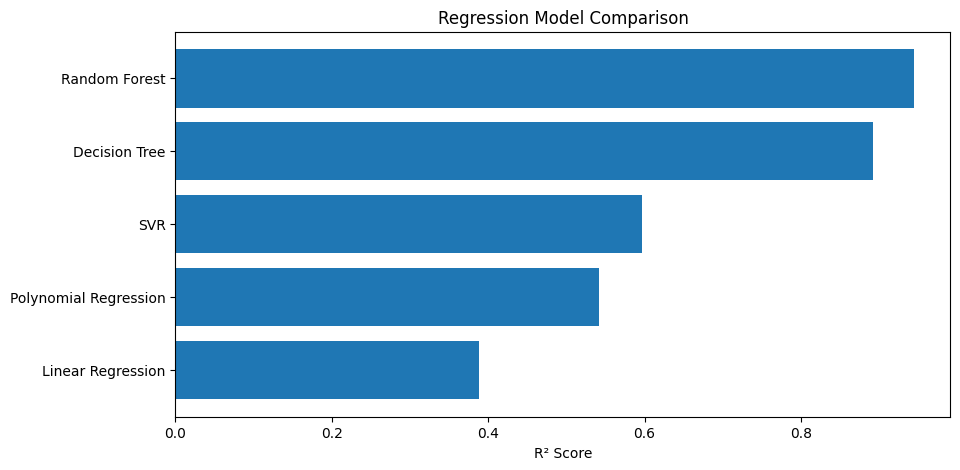

In [ ]:
results_sorted = results.sort_values("R2")

plt.figure(figsize=(10,5))
plt.barh(results_sorted["Model"], results_sorted["R2"])
plt.xlabel("R² Score")
plt.title("Regression Model Comparison")
plt.show()

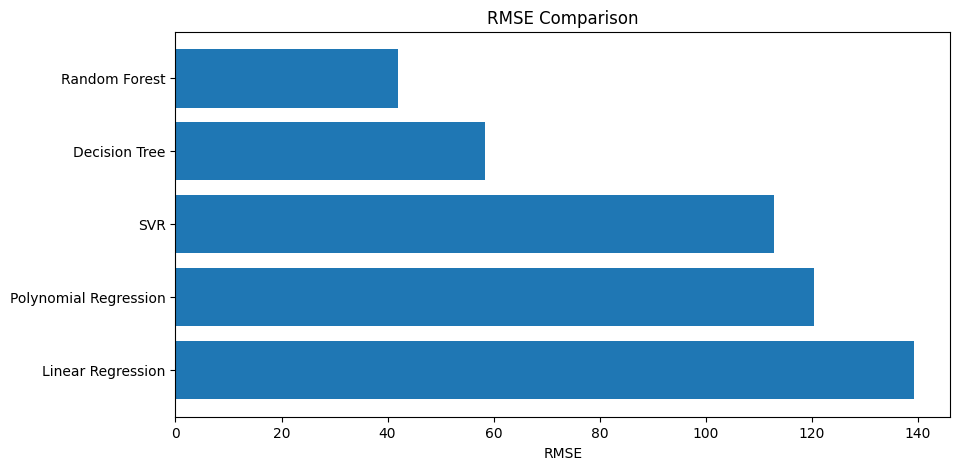

In [ ]:
plt.figure(figsize=(10,5))
plt.barh(results_sorted["Model"], results_sorted["RMSE"])
plt.xlabel("RMSE")
plt.title("RMSE Comparison")
plt.show()

In [ ]:
results.sort_values("R2", ascending=False)\
       .reset_index(drop=True)\
       .style.background_gradient(cmap="Greens")

,Model,R2,MAE,RMSE
0,Random Forest,0.944126,24.892264,42.062756
1,Decision Tree,0.892464,34.199655,58.353847
2,SVR,0.597334,67.942668,112.918478
3,Polynomial Regression,0.541977,91.253424,120.430384
4,Linear Regression,0.387981,104.803351,139.211452


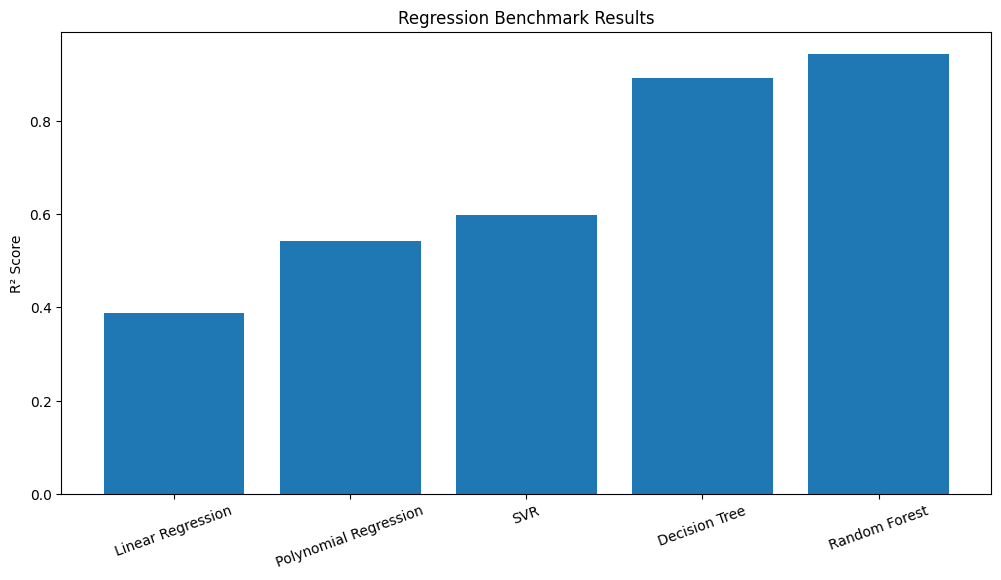

In [ ]:
plt.figure(figsize=(12,6))

plt.bar(results["Model"], results["R2"])

plt.title("Regression Benchmark Results")
plt.ylabel("R² Score")
plt.xticks(rotation=20)

plt.show()